# C9orf72

In [1]:
rm(list=ls())

# LIBRAIRIES AND FUNCTIONS

In [2]:
library(tidyverse)
library(readxl)
library(MetBrewer)
derain <- met.brewer("Derain")
demuth <- met.brewer("Demuth")
cassatt <- met.brewer("Cassatt2")
library(patchwork)
library(ggsci)
library(ggpubr)
source("../src/ggstyles.R")

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
panels <- list(
  list(width = 0.03),
  list(width = 0.1, display = ~variable, fontface = "bold", heading = "Variable"),
  list(width = 0.01, display = ~level),
  list(width = 0.05, display = ~n, hjust = 1, heading = "N."),
  #list(width = 0.05, display = freql, width = 0.05, hjust = 1, heading = "N."),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(
    width = 0.55, item = "forest", hjust = 0.5, heading = "Odds Ratio", linetype = "dashed",
    line_x = 0
  ),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(width = 0.12, display = ~ ifelse(reference, "Reference", sprintf(
    "%0.2f (%0.2f, %0.2f)",
    trans(estimate), trans(conf.low), trans(conf.high)
  )), display_na = NA),
  list(
    width = 0.05,
    display = ~ ifelse(reference, "", format.pval(p.value, digits = 2, eps = 0.001)),
    display_na = NA, hjust = 1, heading = "p"
  ),
  list(width = 0.03)
)

# DATA

In [4]:
# Repeats
dd <- read_excel("../data/ICM_C9_expanded_rawRepeats_withClinical_2025-08-29.xlsx")
# MetaData
dc <- read_excel("../data/ICM_C9_expanded_summary_stats_withClinical_2025-08-29.xlsx")

In [5]:
dim(dd)
dim(dc)

[1] 3348    6

[1] 47 23

# Basics

In [6]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
125425,64,2196.412500000001,1943.4583333333358,1229.9551134932171,2669.733333333332,4083.7833333333338,299.5666666666657,5050.483333333337,0.984375,⋯,0.328125,0.21875,0.203125,0.109375,0.0625,0.015625,Presymptomatic,64,NA,M
125718,64,1952.4075520833335,1697.2833333333328,976.0048584062154,1278.0333333333335,3241.779999999998,231.83333333333337,5426.799999999999,0.96875,⋯,0.25,0.171875,0.078125,0.03125,0.015625,0.015625,Presymptomatic,41,NA,M


In [7]:
dim(dc)
colnames(dc)
length(unique(dc$Sample))

[1] 47 23

[1] "Sample"          "Molecules_count" "Mean"            "Median"         
 [5] "SD"              "Mode"            "P90"             "Min"            
 [9] "Max"             "Prop_gt500"      "Prop_gt1000"     "Prop_gt1500"    
[13] "Prop_gt2000"     "Prop_gt2500"     "Prop_gt3000"     "Prop_gt3500"    
[17] "Prop_gt4000"     "Prop_gt4500"     "Prop_gt5000"     "Condition"      
[21] "AP"              "AO"              "Gender"

[1] 47

In [8]:
table(dc$Condition, exclude=F)


           ALS            FTD Presymptomatic 
            17             23              7 

In [9]:
table(dc$Gender, exclude=F)


 F  M 
25 22 

In [10]:
table(dc$Condition, dc$Gender, exclude=F)

                
                  F  M
  ALS             9  8
  FTD            11 12
  Presymptomatic  5  2

In [11]:
summary(dc$AP)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  31.00   54.50   64.00   61.49   71.00   89.00 

In [12]:
dc$AO <- as.numeric(dc$AO)

Warning message:
“NAs introduits lors de la conversion automatique”


In [13]:
summary(dc$AO)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  35.00   54.00   61.00   59.78   67.00   85.00       6 

In [14]:
head(dd,2)

Sample,repeats,Condition,AP,AO,Gender
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
125425,2669.733333333332,Presymptomatic,64,NA,M
125425,299.5666666666657,Presymptomatic,64,NA,M


In [15]:
length(unique(dd$Sample))

[1] 47

In [16]:
dd$repeats <- as.numeric(dd$repeats)

In [17]:
summary(dd$repeats)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  70.37  994.52 1532.06 1802.39 2364.17 7611.62 

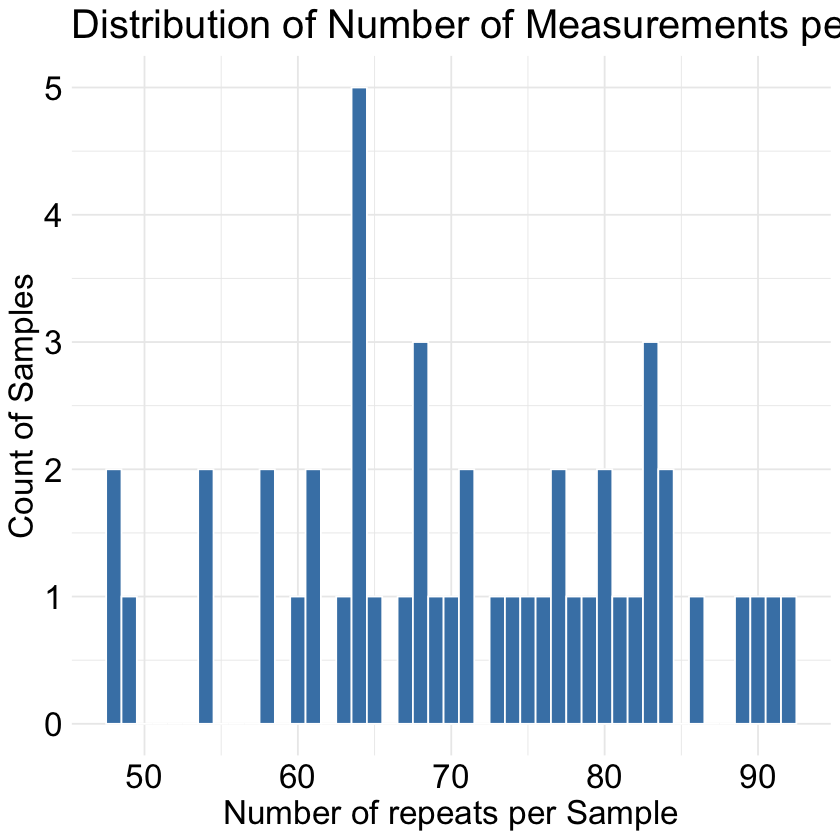

In [18]:
# Number of MUT repeats per sample
dd %>%
  #count(Sample, name = "n_repeats") %>%  # count how many measurements per sample
  group_by(Sample) %>%
  summarise(n_repeats = n()) %>%
  ungroup() %>%
  ggplot(aes(x = n_repeats)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Number of Measurements per Sample",
    x = "Number of repeats per Sample",
    y = "Count of Samples"
  ) +
  theme_minimal() + gtheme(20)

# Explore Length

## Global

In [85]:
dim(dd)

[1] 3348    7

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


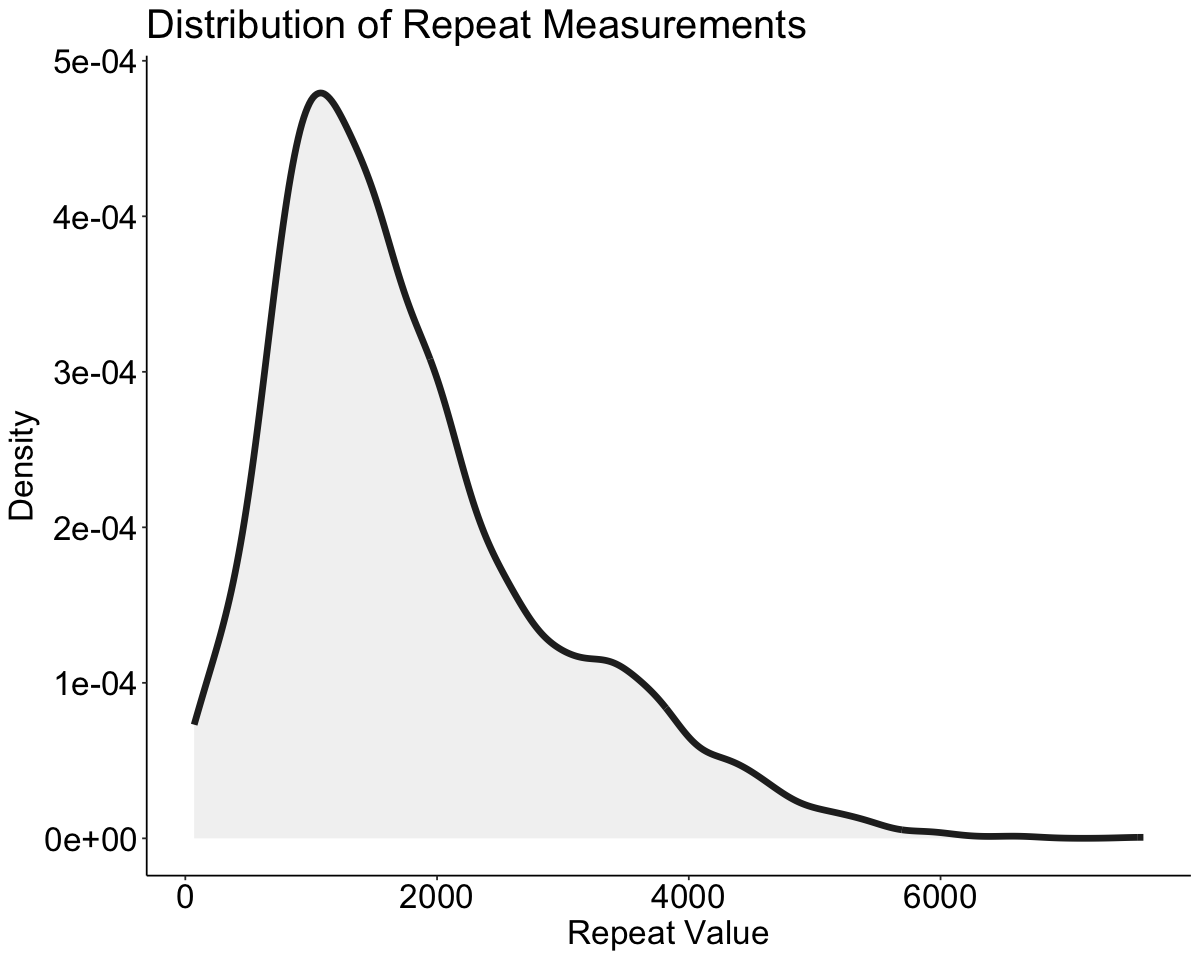

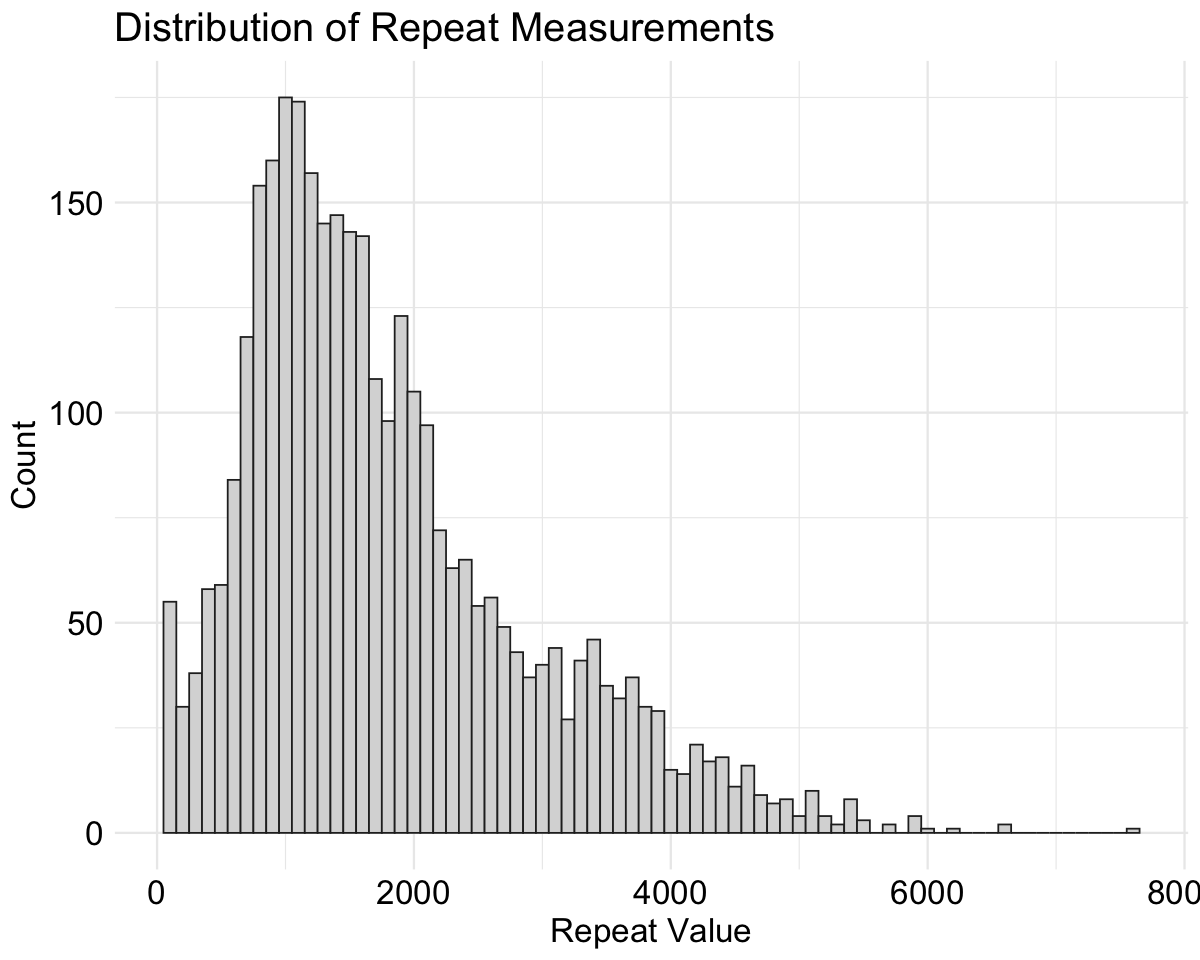

In [19]:
options(repr.plot.width=10, repr.plot.height=8)

ggplot(dd, aes(repeats)) + 
geom_density(size=1.9, fill="grey95", color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  )
#geom_vline(xintercept = c(147, 157, 165), linetype='dashed') + 
#scale_x_continuous(limits=c(90,300), breaks=c(100, 150, 200, 250, 300), guide = guide_axis(n.dodge = 1))

ggplot(dd, aes(x = repeats)) +
  geom_histogram(binwidth = 100, fill = "grey85", color = "grey15") +
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Count"
  ) +
  theme_minimal(base_size = 14) + gtheme(20)

In [21]:
summary(dd$repeats)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  70.37  994.52 1532.06 1802.39 2364.17 7611.62 

## Repeats x Sex

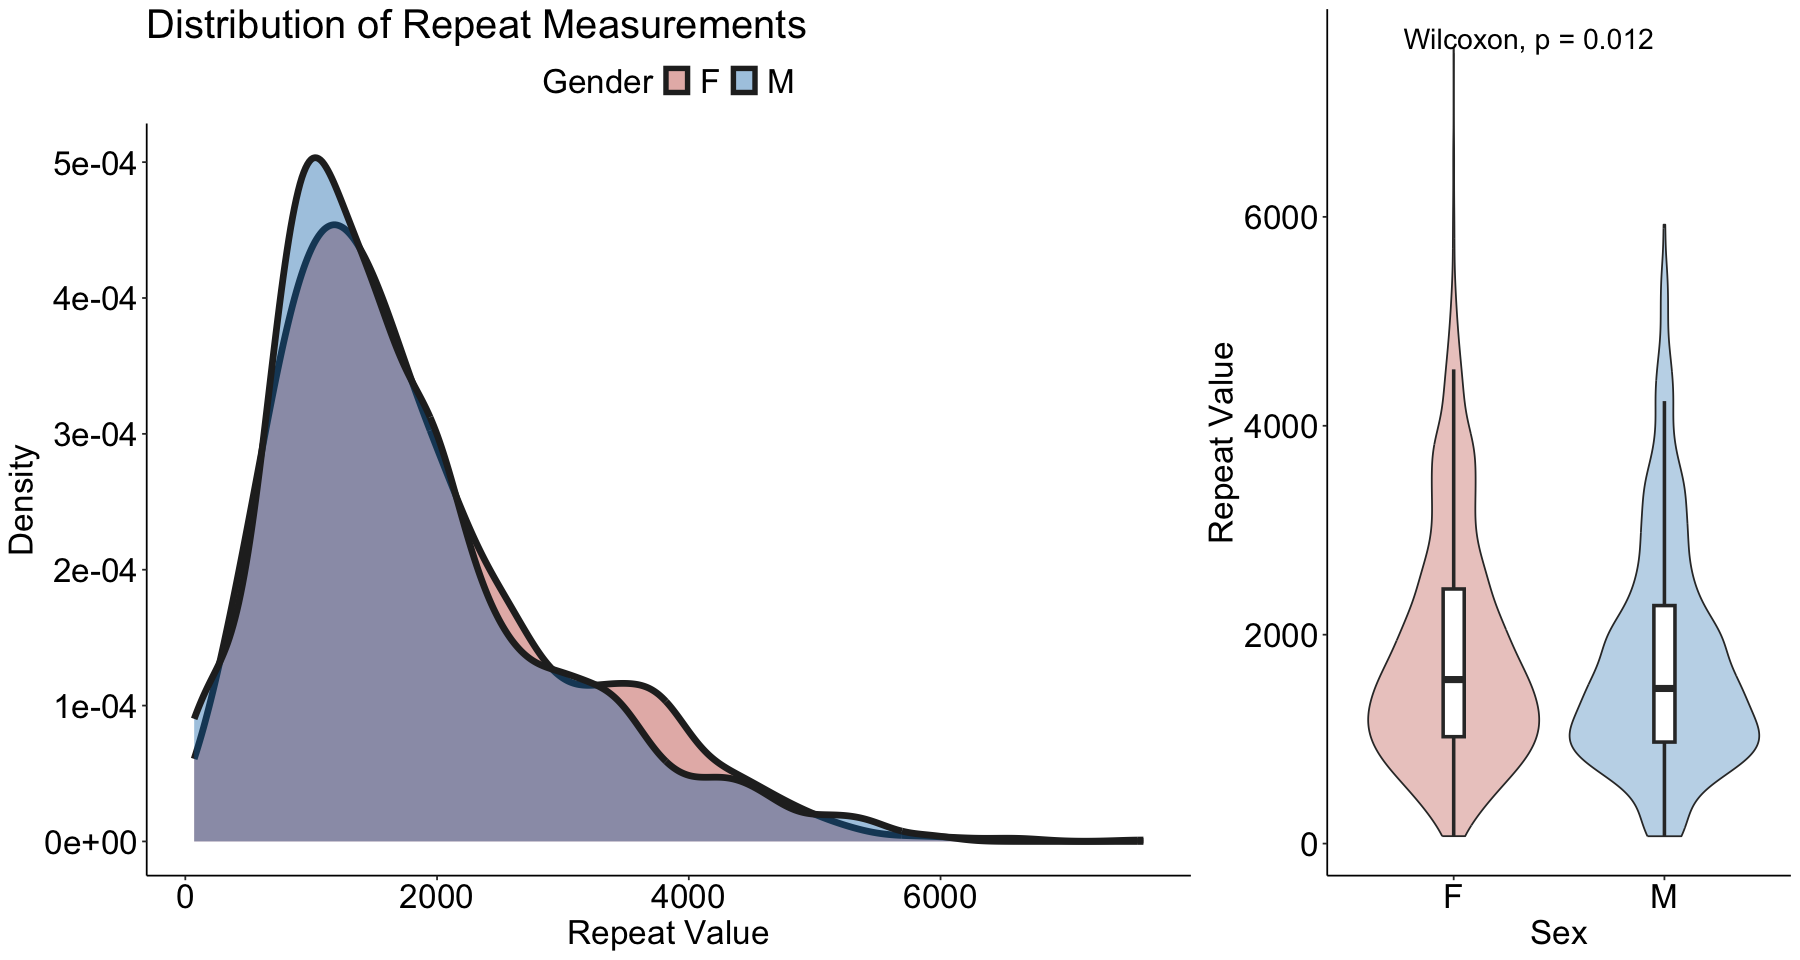

In [92]:
g1 <- ggplot(dd, aes(repeats, fill=Gender)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_nejm(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=Gender)) + 
geom_violin(alpha=.3, aes(fill=Gender)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
#geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(20) + 
  labs(
    #title = "Distribution of Repeat Measurements",
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_nejm(alpha=.4)

options(repr.plot.width=15, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1))

## Repeats x Age

In [98]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
125425,64,2196.412500000001,1943.4583333333358,1229.9551134932171,2669.733333333332,4083.7833333333338,299.5666666666657,5050.483333333337,0.984375,⋯,0.328125,0.21875,0.203125,0.109375,0.0625,0.015625,Presymptomatic,64,NA,M
125718,64,1952.4075520833335,1697.2833333333328,976.0048584062154,1278.0333333333335,3241.779999999998,231.83333333333337,5426.799999999999,0.96875,⋯,0.25,0.171875,0.078125,0.03125,0.015625,0.015625,Presymptomatic,41,NA,M


In [99]:
summary(dc$AP)
dd$group_age <- "64-"
dd$group_age[which(dd$AP >= 64)] <- "64+"
dd$group_age <- factor(dd$group_age, levels=c("64-","64+"))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  31.00   54.50   64.00   61.49   71.00   89.00 

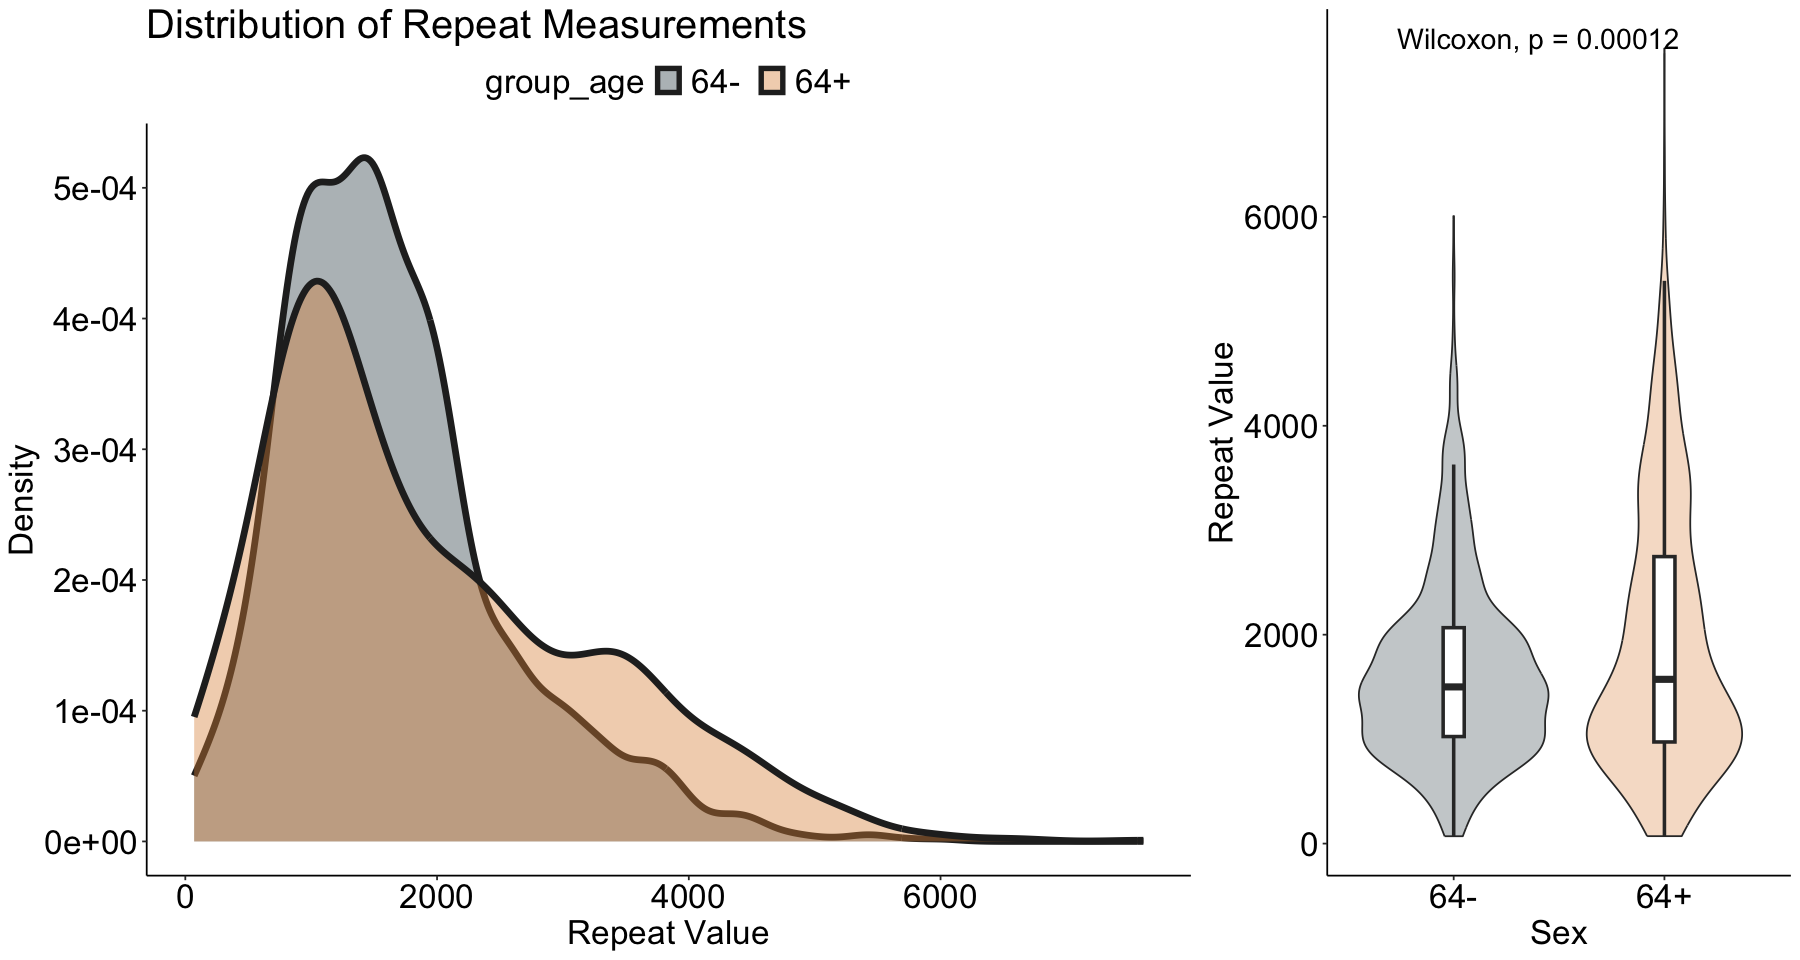

In [102]:
options(repr.plot.width=10, repr.plot.height=8)

g1 <- ggplot(dd, aes(repeats, fill=group_age)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_jama(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=group_age)) + 
geom_violin(alpha=.3, aes(fill=group_age)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
theme_classic() + gtheme(20) + 
  labs(
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_jama(alpha=.4)

options(repr.plot.width=15, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1))

## Repeats x Condition

In [103]:
table(dc$Condition)


           ALS            FTD Presymptomatic 
            17             23              7 

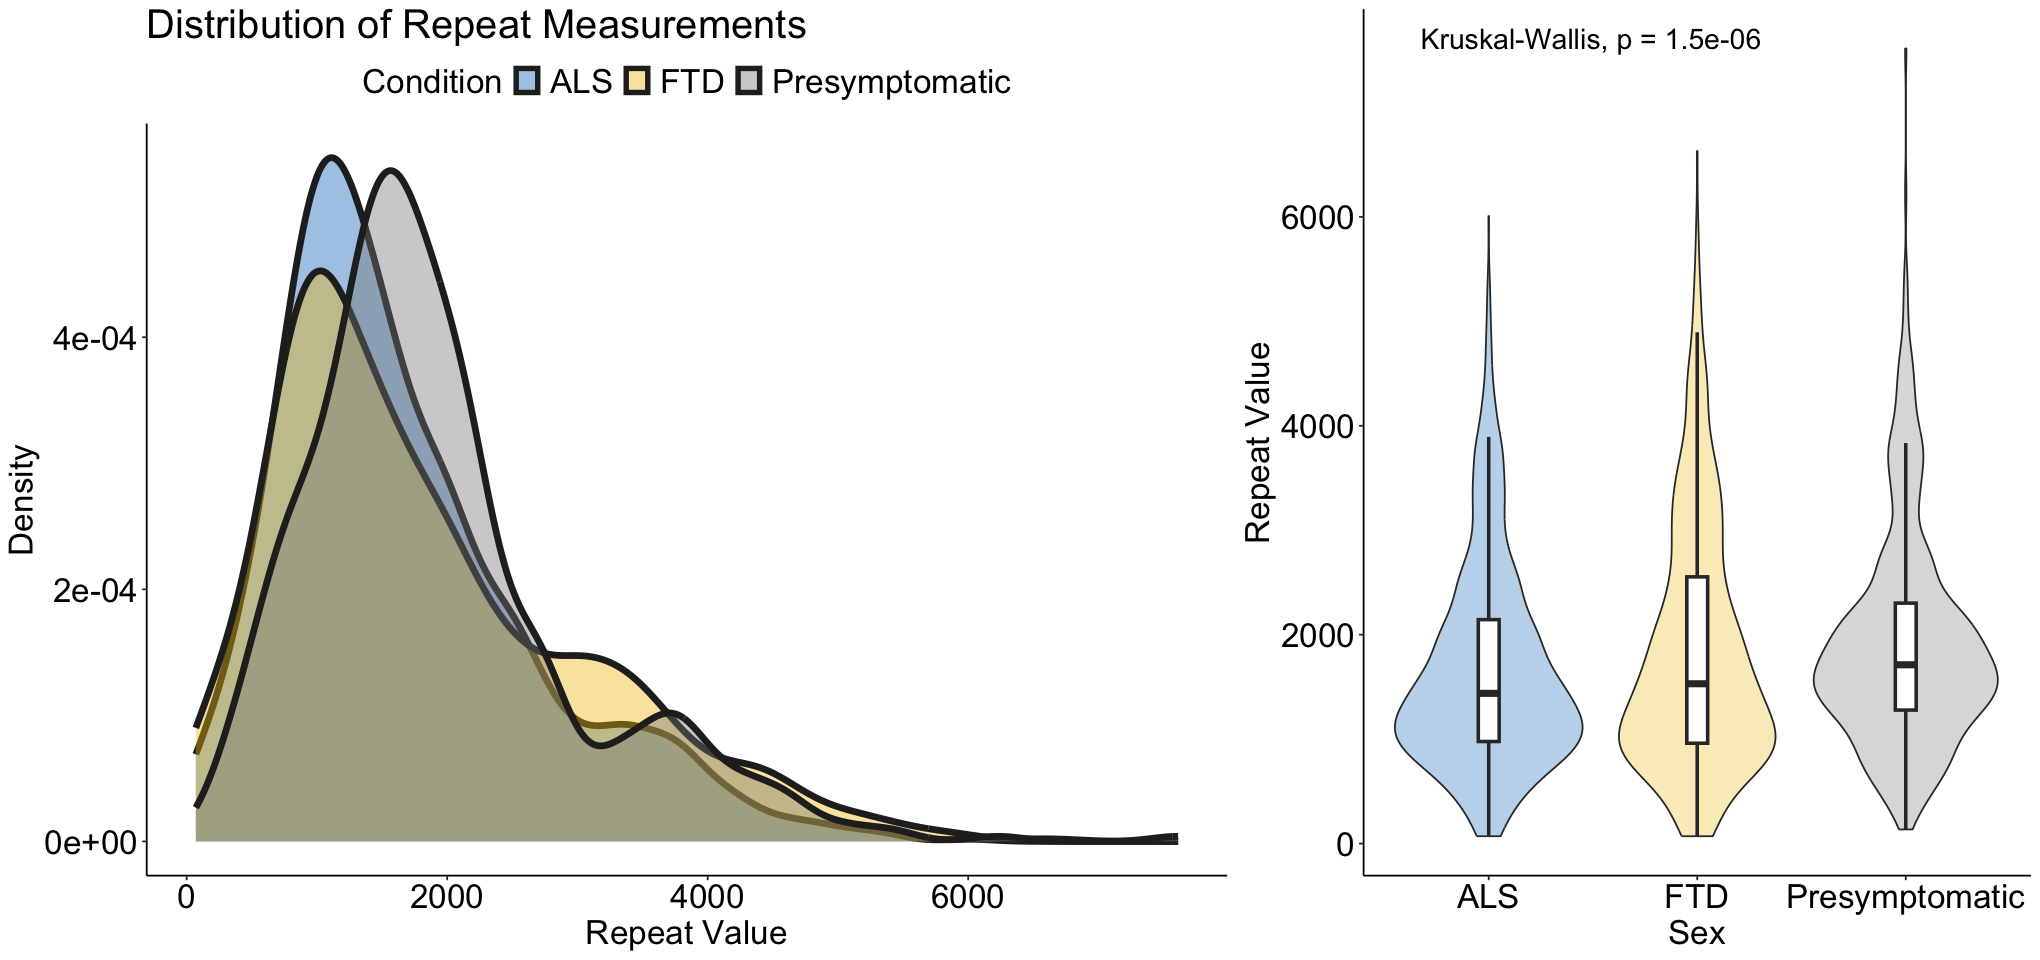

In [107]:
g1 <- ggplot(dd, aes(repeats, fill=Condition)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_jco(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=Condition)) + 
geom_violin(alpha=.3, aes(fill=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
theme_classic() + gtheme(20) + 
  labs(
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_jco(alpha=.4)

options(repr.plot.width=17, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1.3))

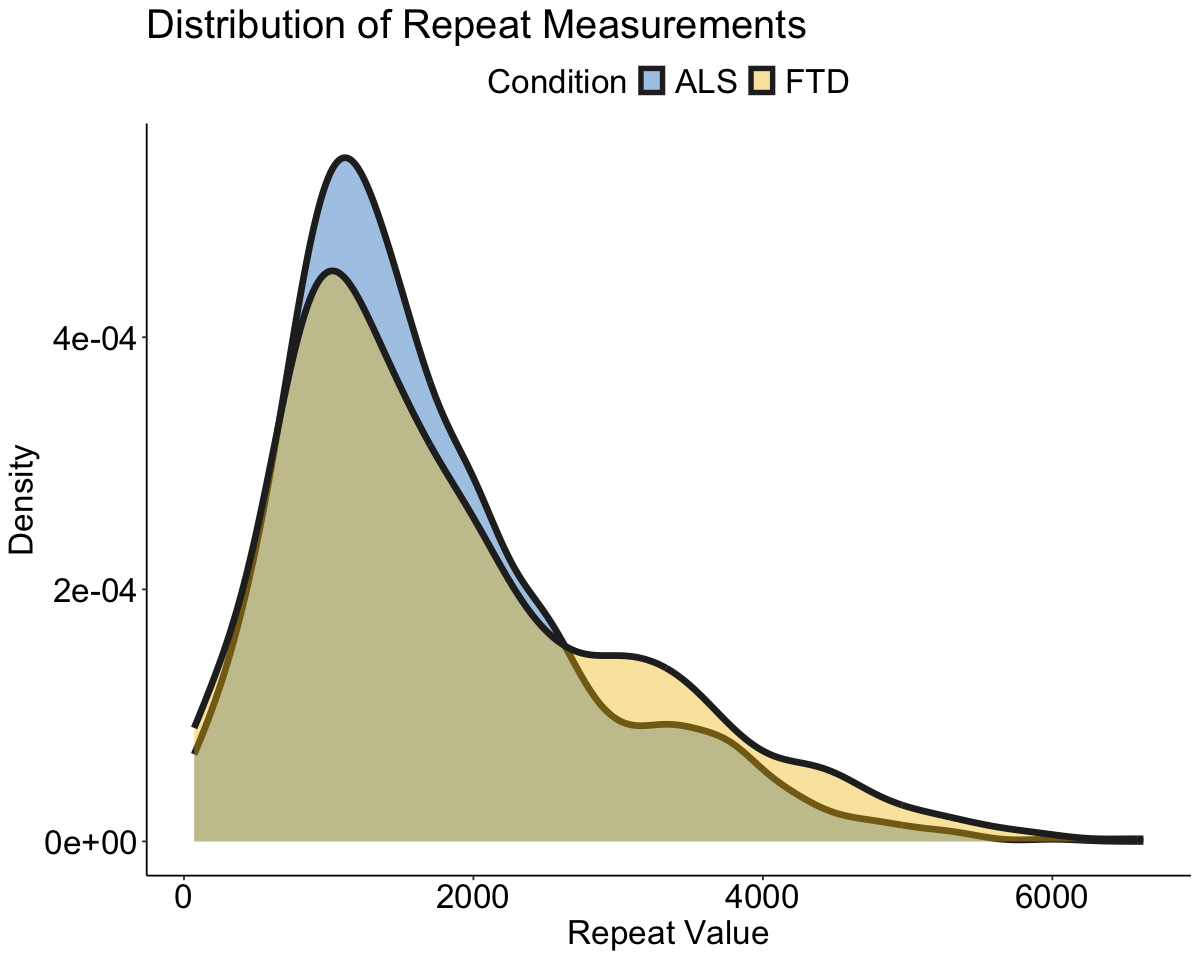

In [108]:
options(repr.plot.width=10, repr.plot.height=8)

dd %>% filter(Condition %in% c("ALS","FTD")) %>% ggplot(aes(repeats, fill=Condition)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_jco(alpha=.4)

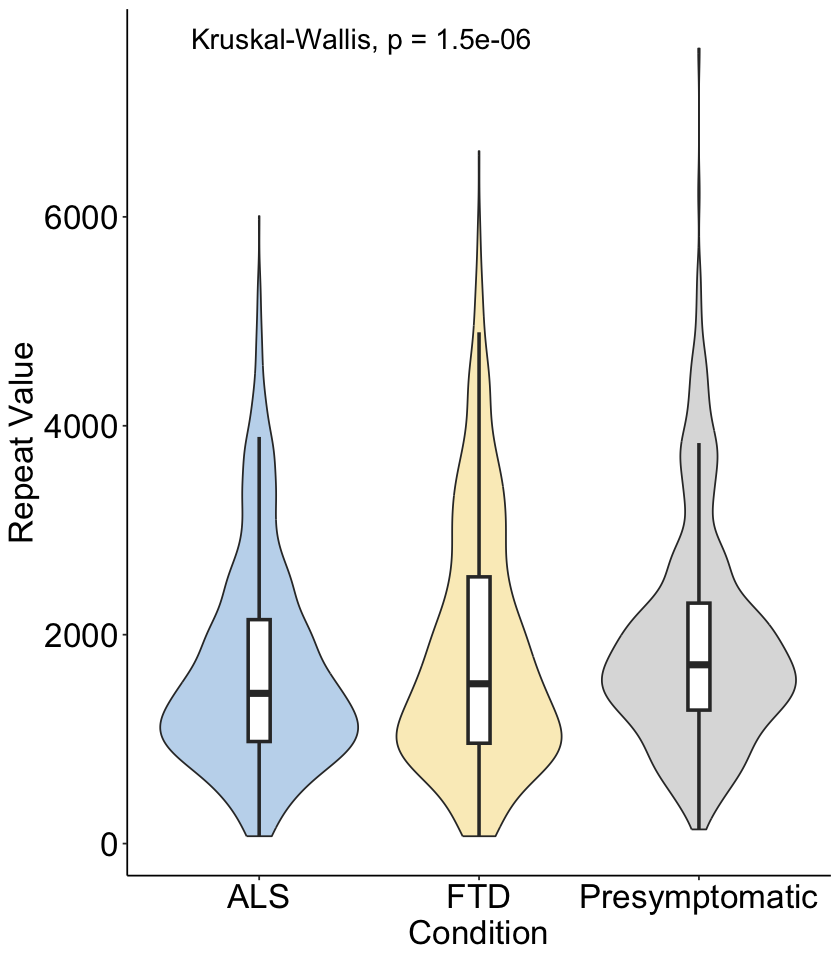

In [32]:
options(repr.plot.width=7, repr.plot.height=8)

ggplot(dd, aes(y=repeats, x=Condition)) + 
geom_violin(alpha=.3, aes(fill=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
#geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(20) + 
  labs(
    #title = "Distribution of Repeat Measurements",
    y = "Repeat Value",
    x = "Condition"
  ) + noleg + stat_compare_means(size=6) + scale_fill_jco(alpha=.4)

# Size Region Enrichment 

`geom_smooth()` using formula = 'y ~ x'


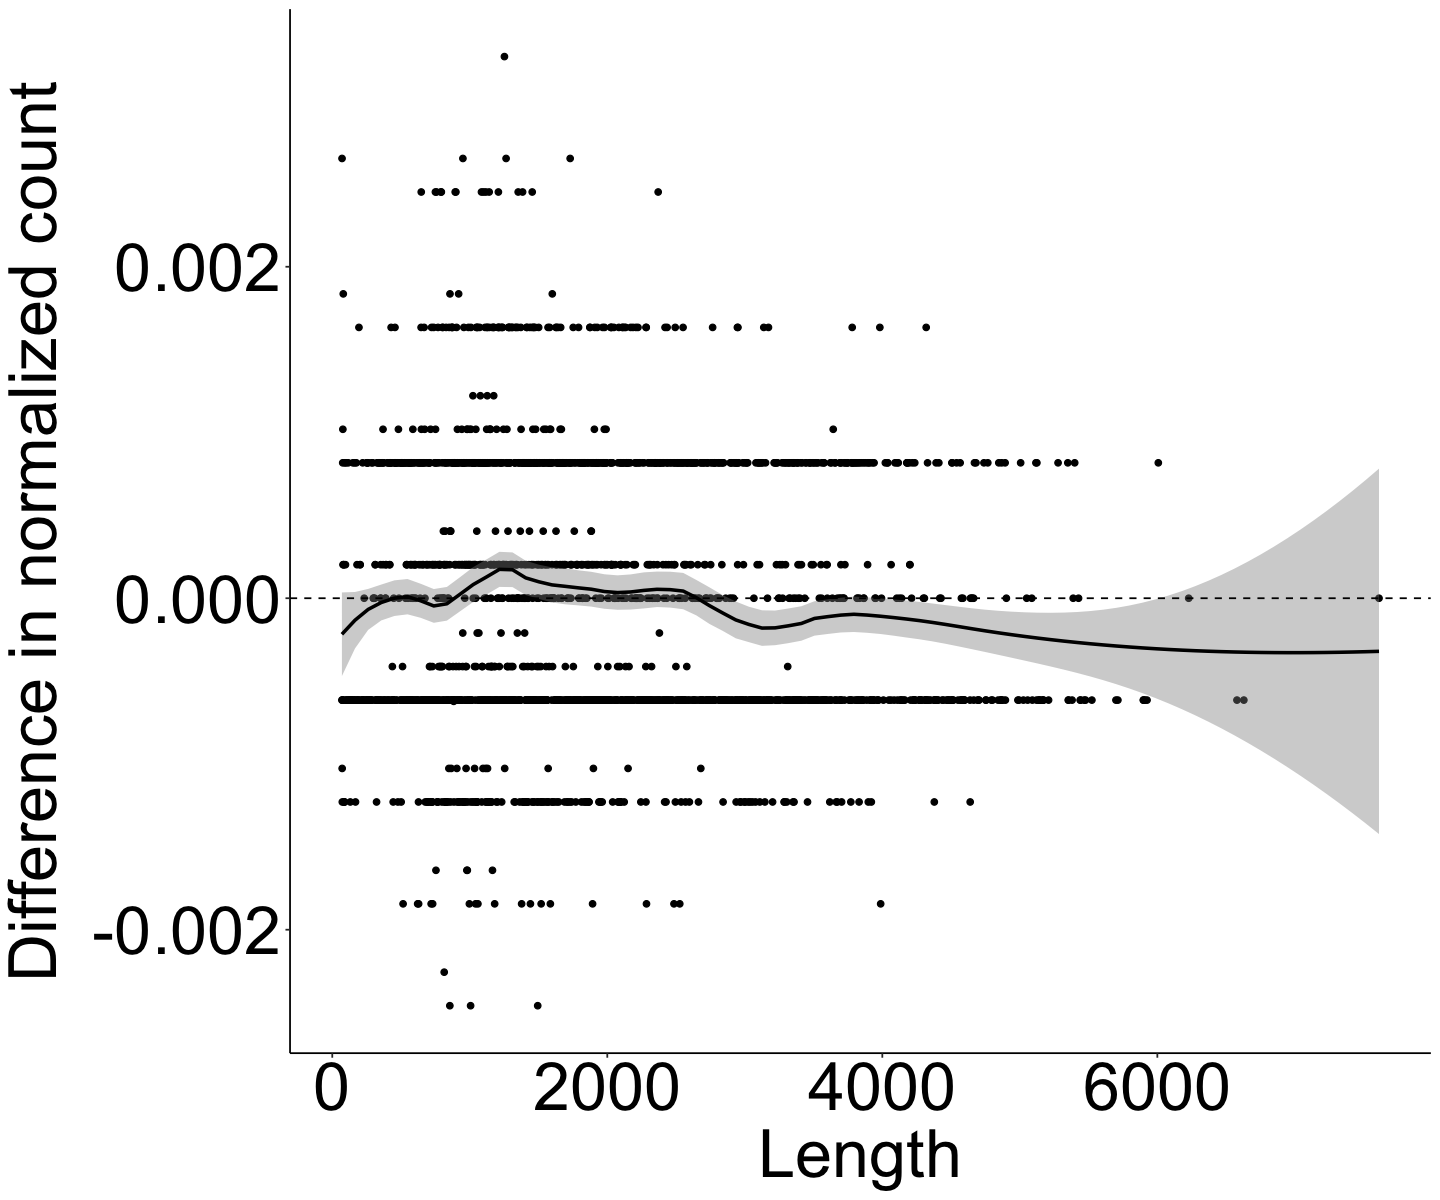

In [33]:
# Calculate Counts and Props 
dregions <- dd %>% 
group_by(Condition, round(repeats), .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0) %>% rename(Repeat = "round(repeats)")
dregions$diff_ALS_FTD <- dregions$prop_ALS -  dregions$prop_FTD

options(repr.plot.width=12,repr.plot.height=10)

ggplot(dregions, aes(x = Repeat, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(40) + 
  xlab("Length") +
  ylab("Difference in normalized count")

## With binning

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


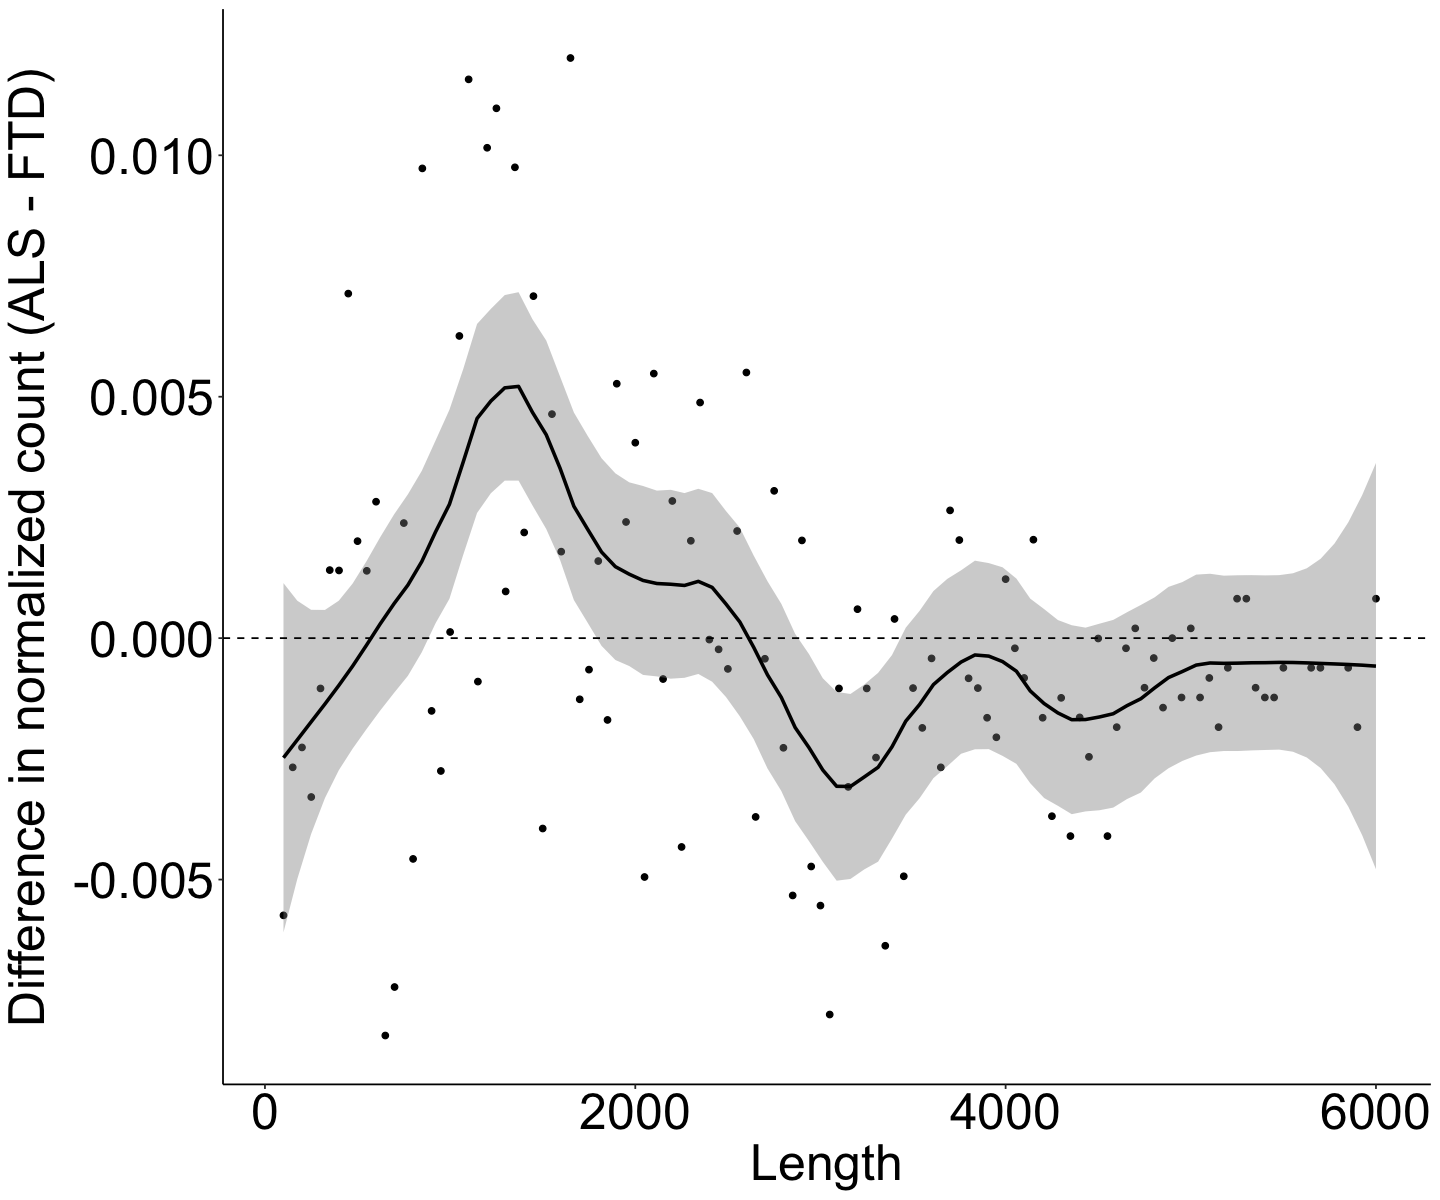

In [34]:
bin_size <- 50

dd_binned <- dd %>%
  mutate(
    repeat_bin = floor(repeats / bin_size) * bin_size
  )

dregions <- dd_binned %>% 
group_by(Condition, repeat_bin, .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0)
dregions$diff_ALS_FTD <- dregions$prop_ALS -  dregions$prop_FTD

options(repr.plot.width=12,repr.plot.height=10)

ggplot(dregions, aes(x = repeat_bin, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(30) + 
  xlab("Length") +
  ylab("Difference in normalized count (ALS - FTD)") + 
  scale_x_continuous(limits=c(70,6000))
#geom_vline()
#, breaks=c(100, 150, 200, 250, 300), guide = guide_axis(n.dodge = 1))

In [35]:
#seq(100,6000,50) %in% sort(unique(dd_binned$repeat_bin))

# Patient-level metrics

In [36]:
head(dd,2)

Sample,repeats,Condition,AP,AO,Gender,group_age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>
125425,2669.7333,Presymptomatic,64,NA,M,64+
125425,299.5667,Presymptomatic,64,NA,M,64+


In [37]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
125425,64,2196.412500000001,1943.4583333333358,1229.9551134932171,2669.733333333332,4083.7833333333338,299.5666666666657,5050.483333333337,0.984375,⋯,0.328125,0.21875,0.203125,0.109375,0.0625,0.015625,Presymptomatic,64,NA,M
125718,64,1952.4075520833335,1697.2833333333328,976.0048584062154,1278.0333333333335,3241.779999999998,231.83333333333337,5426.799999999999,0.96875,⋯,0.25,0.171875,0.078125,0.03125,0.015625,0.015625,Presymptomatic,41,NA,M


In [38]:
df <- dd %>%
group_by(Sample, AP, AO, Gender, group_age, Condition) %>%
summarise(
    n_molecules = n(),
    mean = mean(repeats),
    median = median(repeats),
    min = min(repeats),
    max = max(repeats),
    sd = sd(repeats),
    n_2000 = sum(repeats < 2000),
    n_3000 = sum(repeats < 3000),
    n_4000 = sum(repeats < 4000),
    m_2000 = sum(repeats > 2000),
    m_3000 = sum(repeats > 3000),
    m_4000 = sum(repeats > 4000)
)
df$prop_2000 <- df$n_2000 / df$n_molecules
df$prop_3000 <- df$n_3000 / df$n_molecules
df$prop_4000 <- df$n_4000 / df$n_molecules
df$mprop_2000 <- df$m_2000 / df$n_molecules
df$mprop_3000 <- df$m_3000 / df$n_molecules
df$mprop_4000 <- df$m_4000 / df$n_molecules

df$Condition <- gsub("Presymptomatic","Pre",df$Condition)

head(df,3)

`summarise()` has grouped output by 'Sample', 'AP', 'AO', 'Gender', 'group_age'. You can override using the `.groups`
argument.


Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125425,64,NA,M,64+,Pre,64,2196.413,1943.458,299.56667,⋯,57,30,14,7,0.5312500,0.7812500,0.8906250,0.4687500,0.2187500,0.10937500
125718,41,NA,M,64-,Pre,64,1952.408,1697.283,231.83333,⋯,62,24,11,2,0.6250000,0.8281250,0.9687500,0.3750000,0.1718750,0.03125000
125839,65,63,F,64+,FTD,83,1880.500,1261.817,71.53333,⋯,76,25,15,7,0.6987952,0.8192771,0.9156627,0.3012048,0.1807229,0.08433735


In [39]:
summary(df$n_molecules)
summary(dc$Molecules_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   64.00   71.00   71.23   80.50   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   64.00   71.00   71.23   80.50   92.00 

In [40]:
summary(df$prop_4000)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7297  0.9226  0.9767  0.9508  1.0000  1.0000 

# Compare patient-level ALS vs. FTD

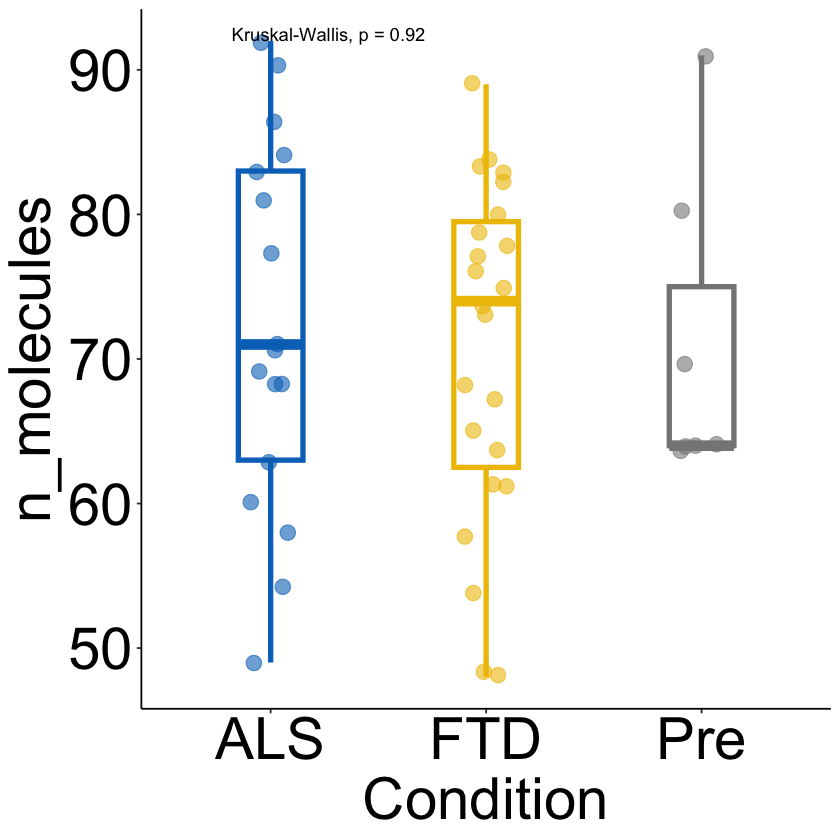

In [41]:
options(repr.plot.width=7, repr.plot.height=7)

ggplot(df, aes(x=Condition, y=n_molecules, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

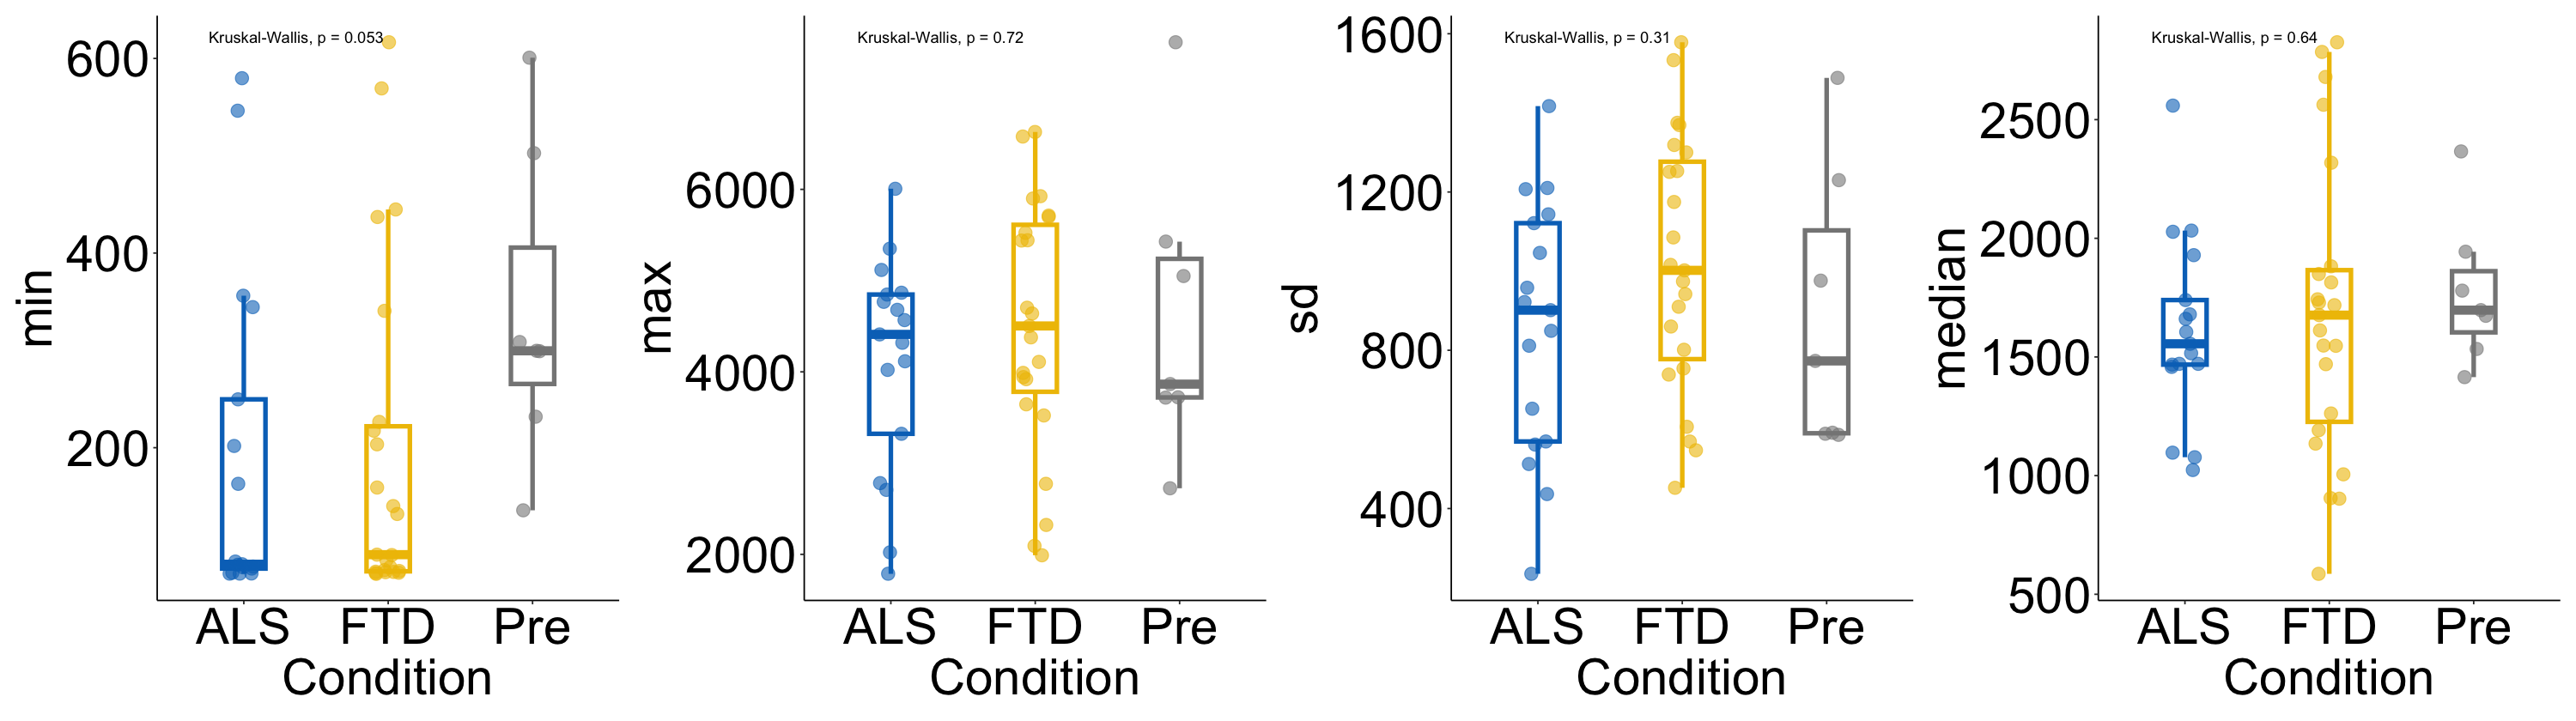

In [42]:
gmin <- ggplot(df, aes(x=Condition, y=min, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gmax <- ggplot(df, aes(x=Condition, y=max, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gsd <- ggplot(df, aes(x=Condition, y=sd, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gmedian <- ggplot(df, aes(x=Condition, y=median, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gmin + gmax + gsd + gmedian + plot_layout(ncol = 4)

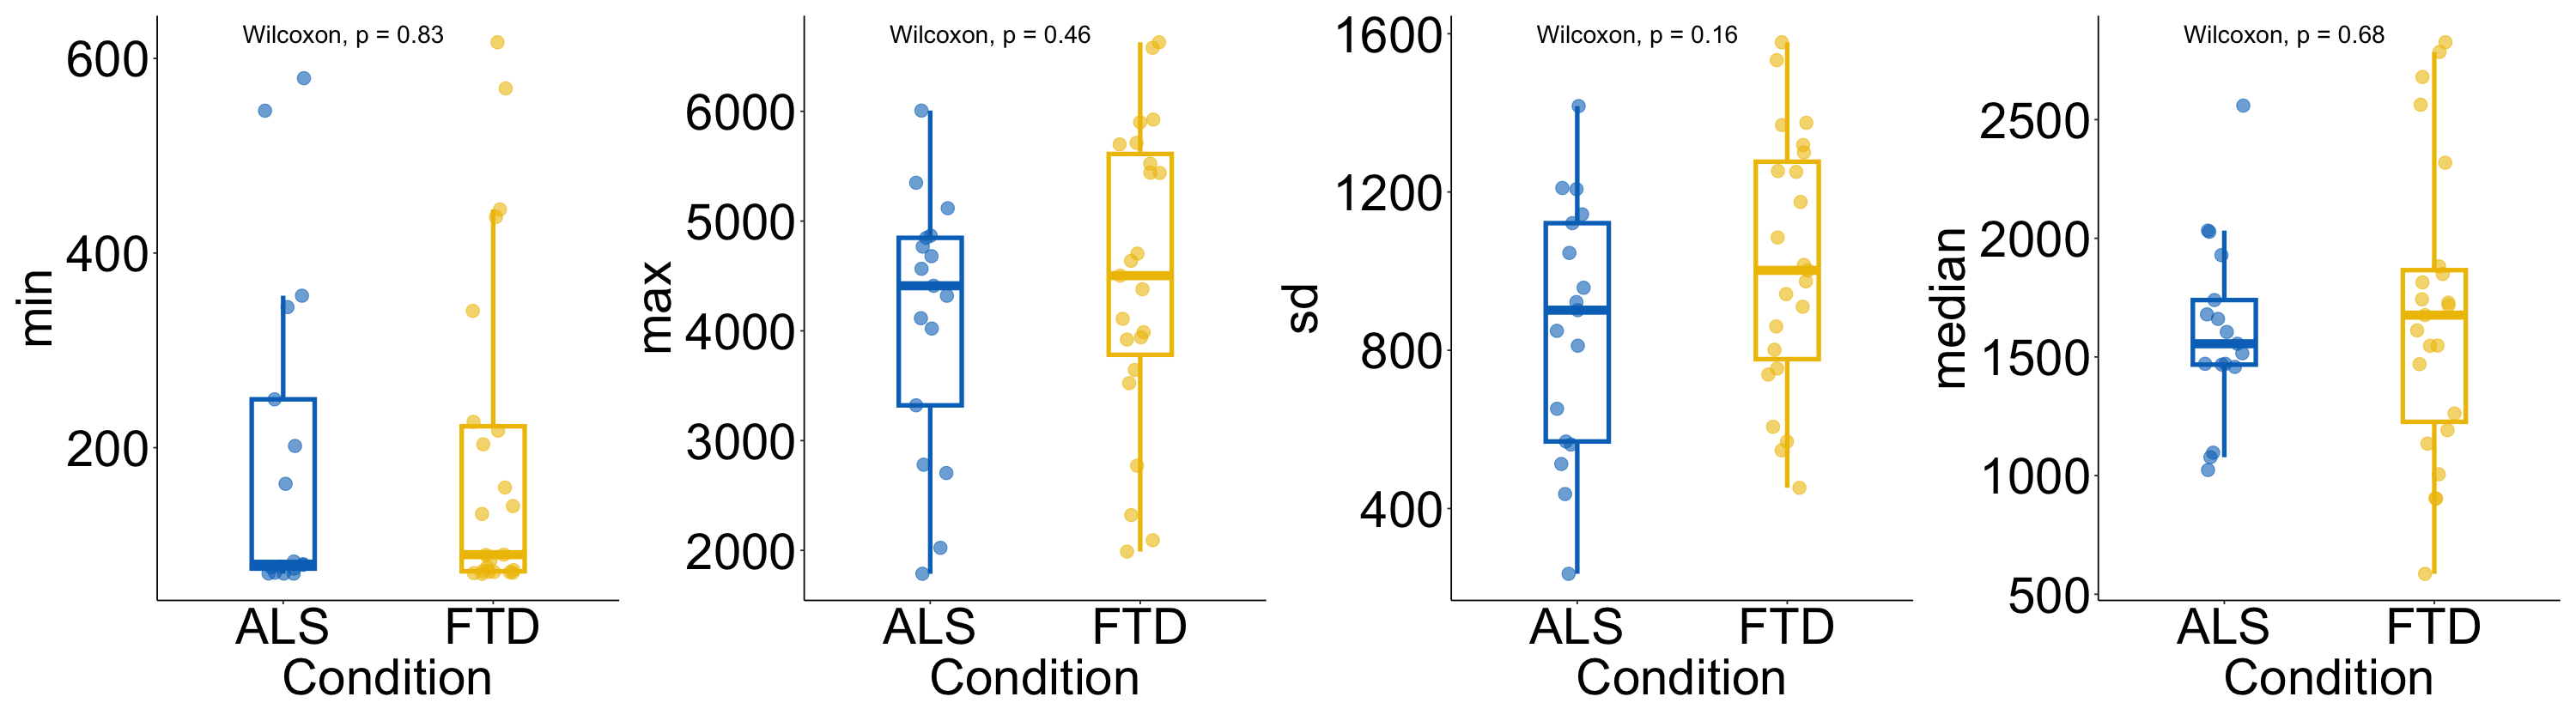

In [43]:
dff <- df %>% filter(Condition %in% c("ALS","FTD"))

gmin <- ggplot(dff, aes(x=Condition, y=min, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gmax <- ggplot(dff, aes(x=Condition, y=max, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gsd <- ggplot(dff, aes(x=Condition, y=sd, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gmedian <- ggplot(dff, aes(x=Condition, y=median, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gmin + gmax + gsd + gmedian + plot_layout(ncol = 4)

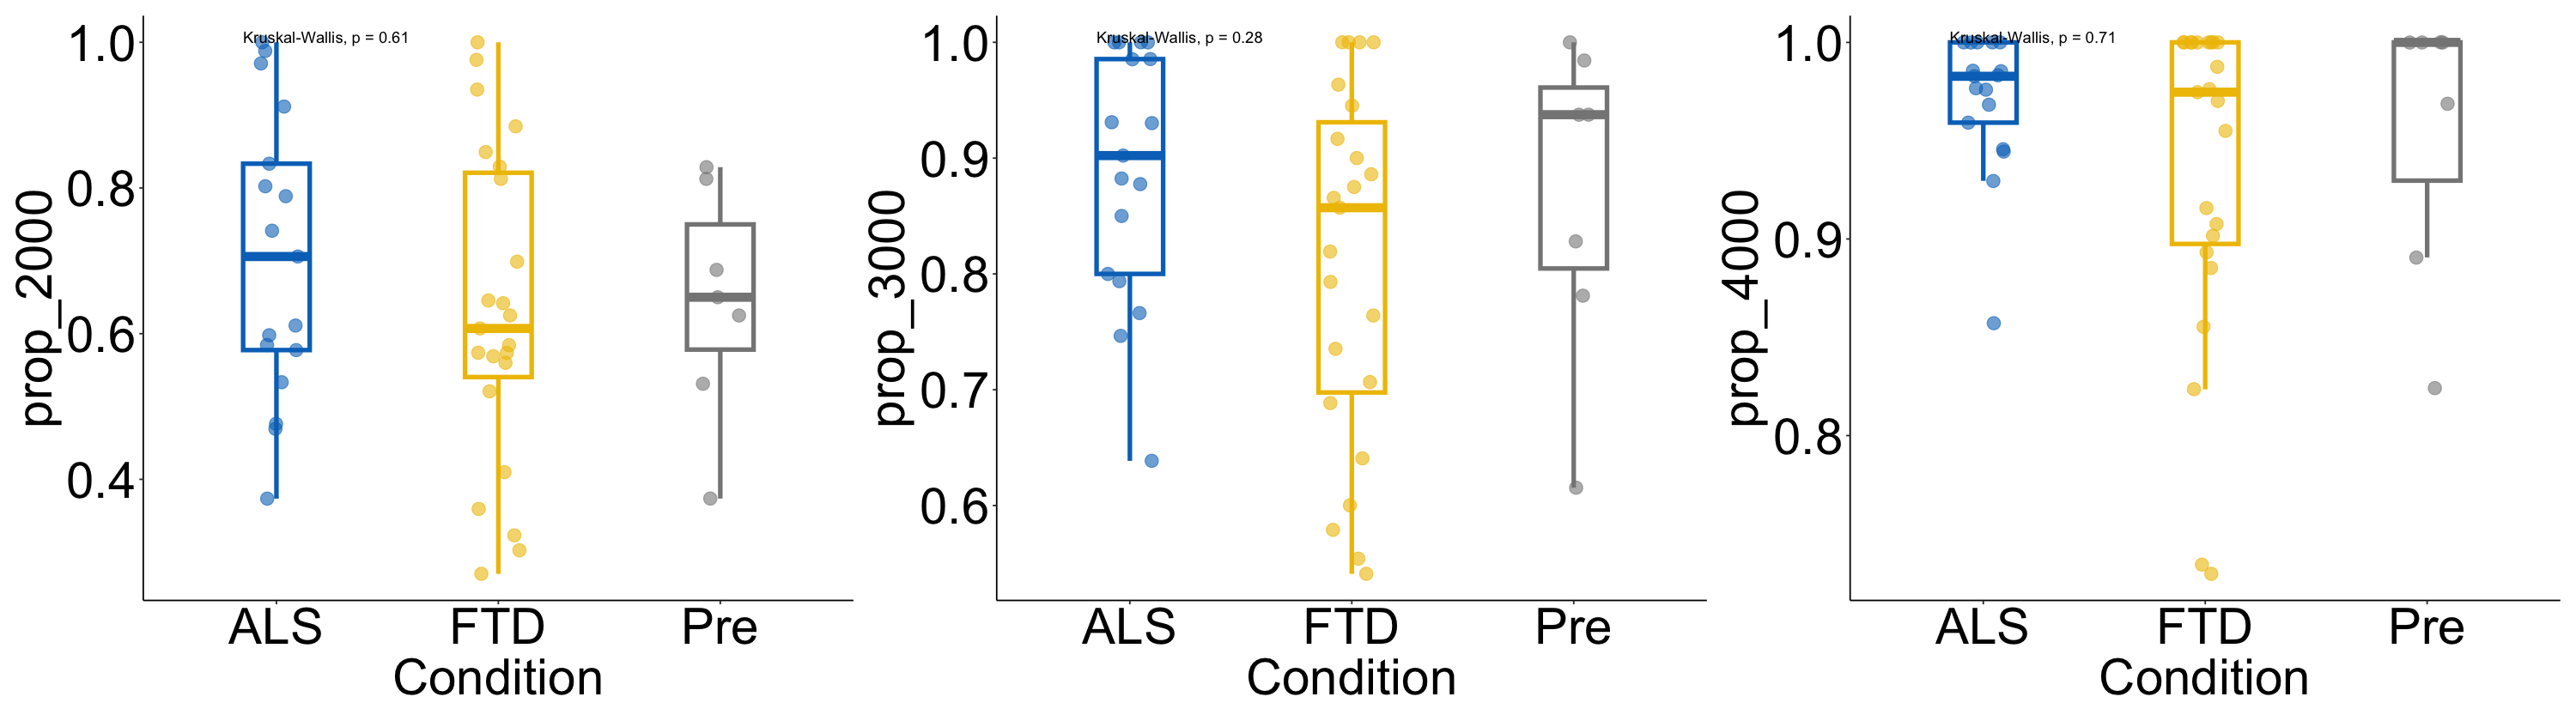

In [44]:
gprop_2000 <- ggplot(df, aes(x=Condition, y=prop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(df, aes(x=Condition, y=prop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(df, aes(x=Condition, y=prop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

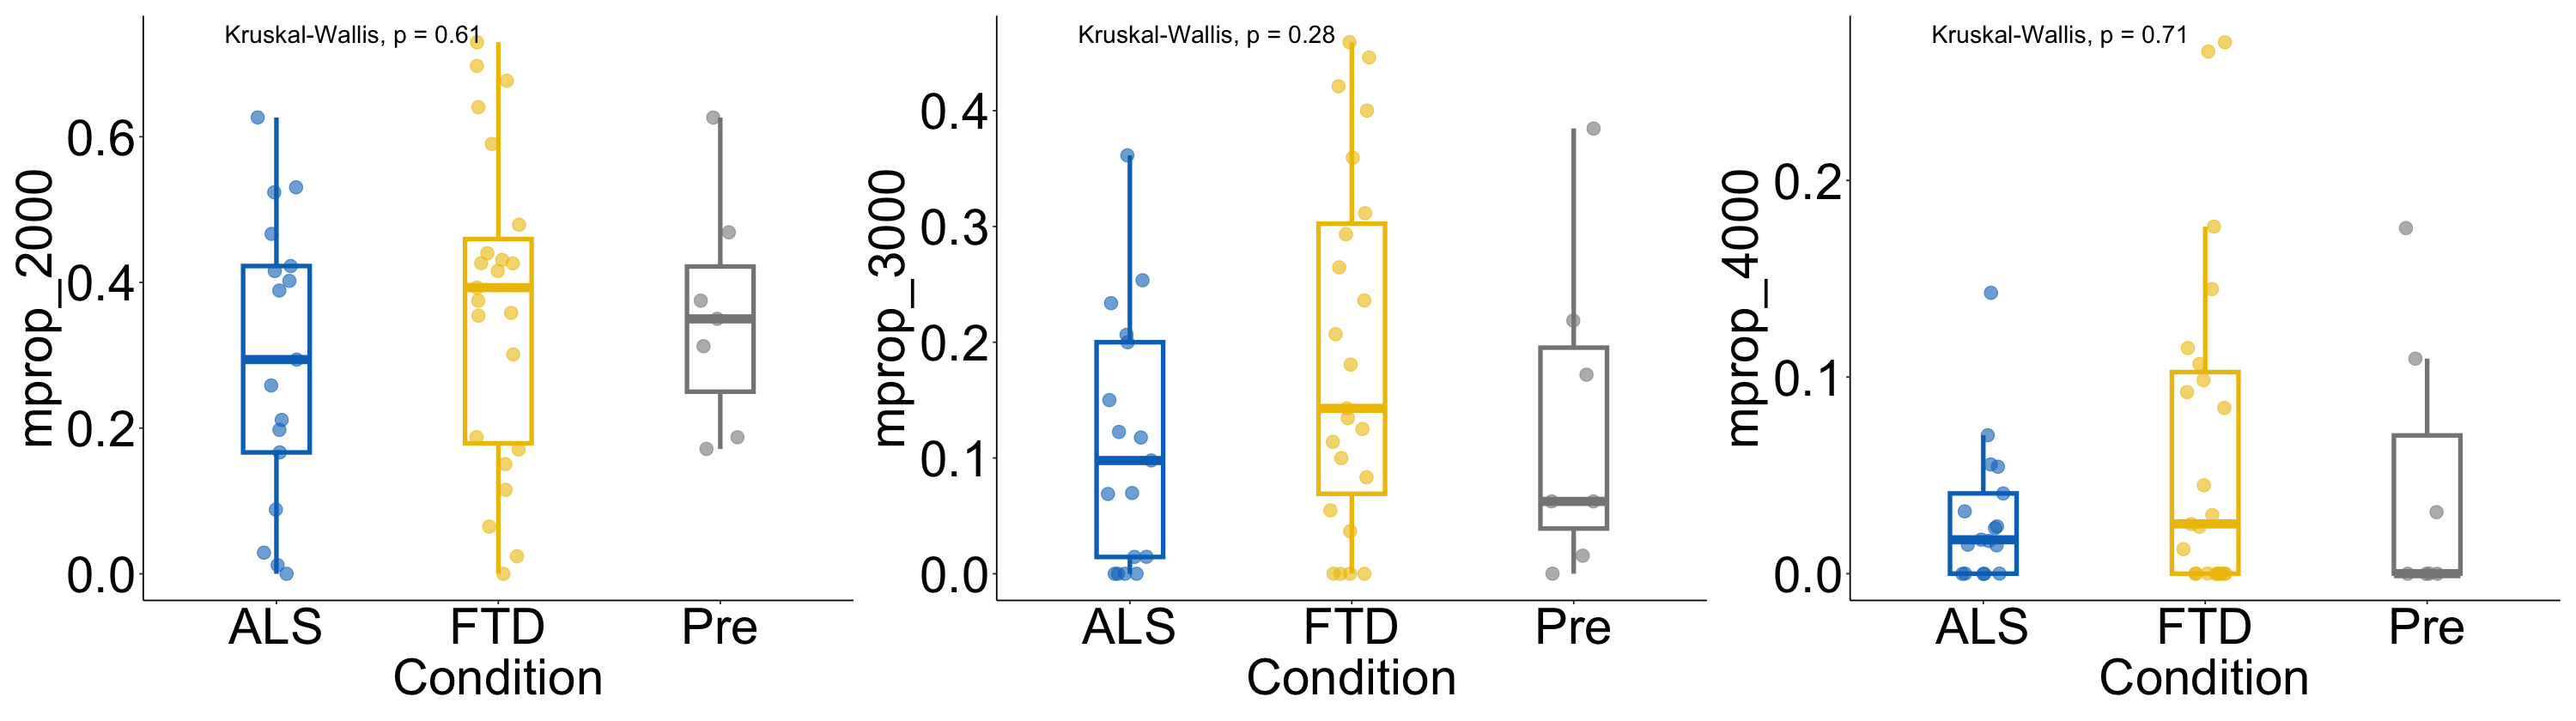

In [110]:
gprop_2000 <- ggplot(df, aes(x=Condition, y=mprop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(df, aes(x=Condition, y=mprop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(df, aes(x=Condition, y=mprop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

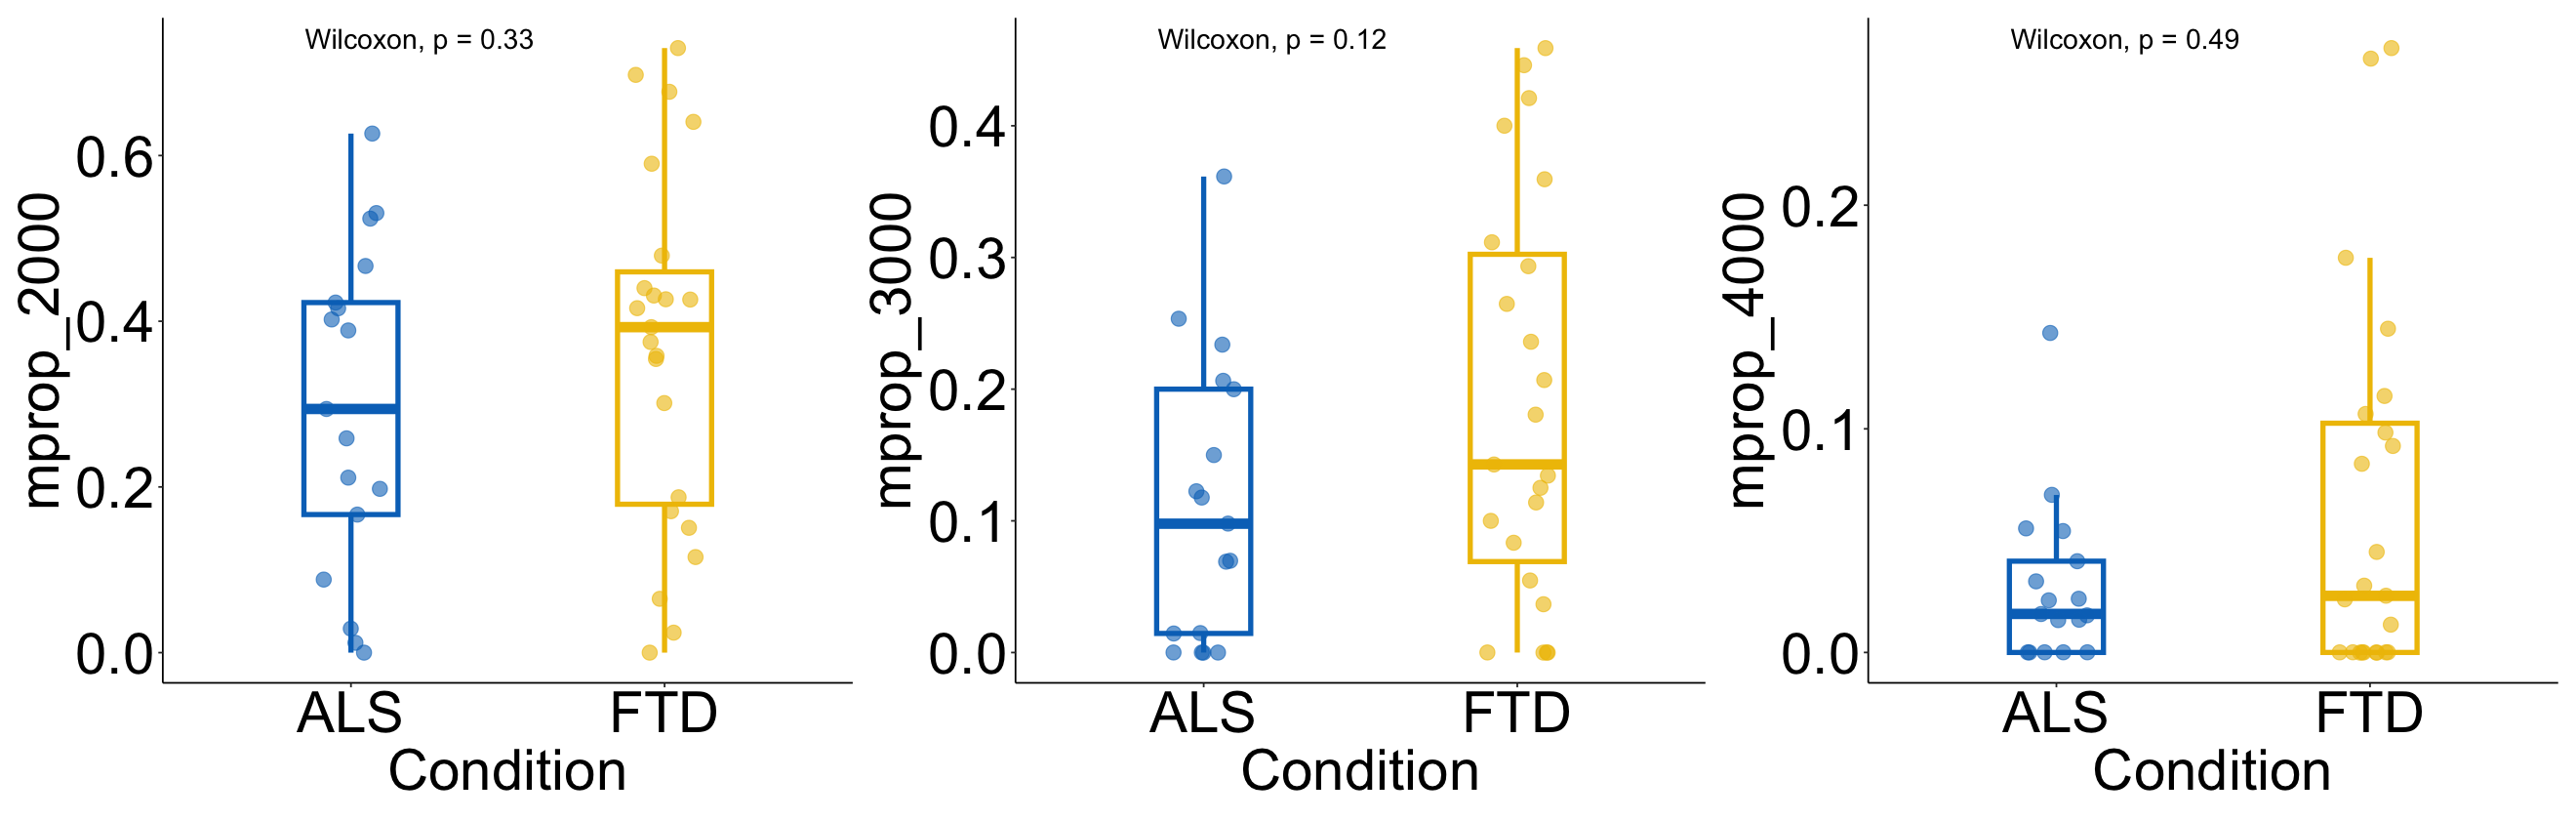

In [112]:
gprop_2000 <- ggplot(dff, aes(x=Condition, y=mprop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(dff, aes(x=Condition, y=mprop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(dff, aes(x=Condition, y=mprop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=22, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

# Predictive Model for Repeats Length

In [48]:
head(dd,3)

Sample,repeats,Condition,AP,AO,Gender,group_age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>
125425,2669.7333,Presymptomatic,64,NA,M,64+
125425,299.5667,Presymptomatic,64,NA,M,64+
125425,2365.0000,Presymptomatic,64,NA,M,64+


[1] 3348    7


Call:  glm(formula = repeats ~ Age10 + Gender + Condition, family = "gaussian", 
    data = tmp)

Coefficients:
            (Intercept)                    Age10                  GenderM  
                1076.07                   104.27                   -96.22  
           ConditionFTD  ConditionPresymptomatic  
                 142.82                   391.74  

Degrees of Freedom: 3347 Total (i.e. Null);  3343 Residual
Null Deviance:	    4.147e+09 
Residual Deviance: 4.069e+09 	AIC: 56420

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


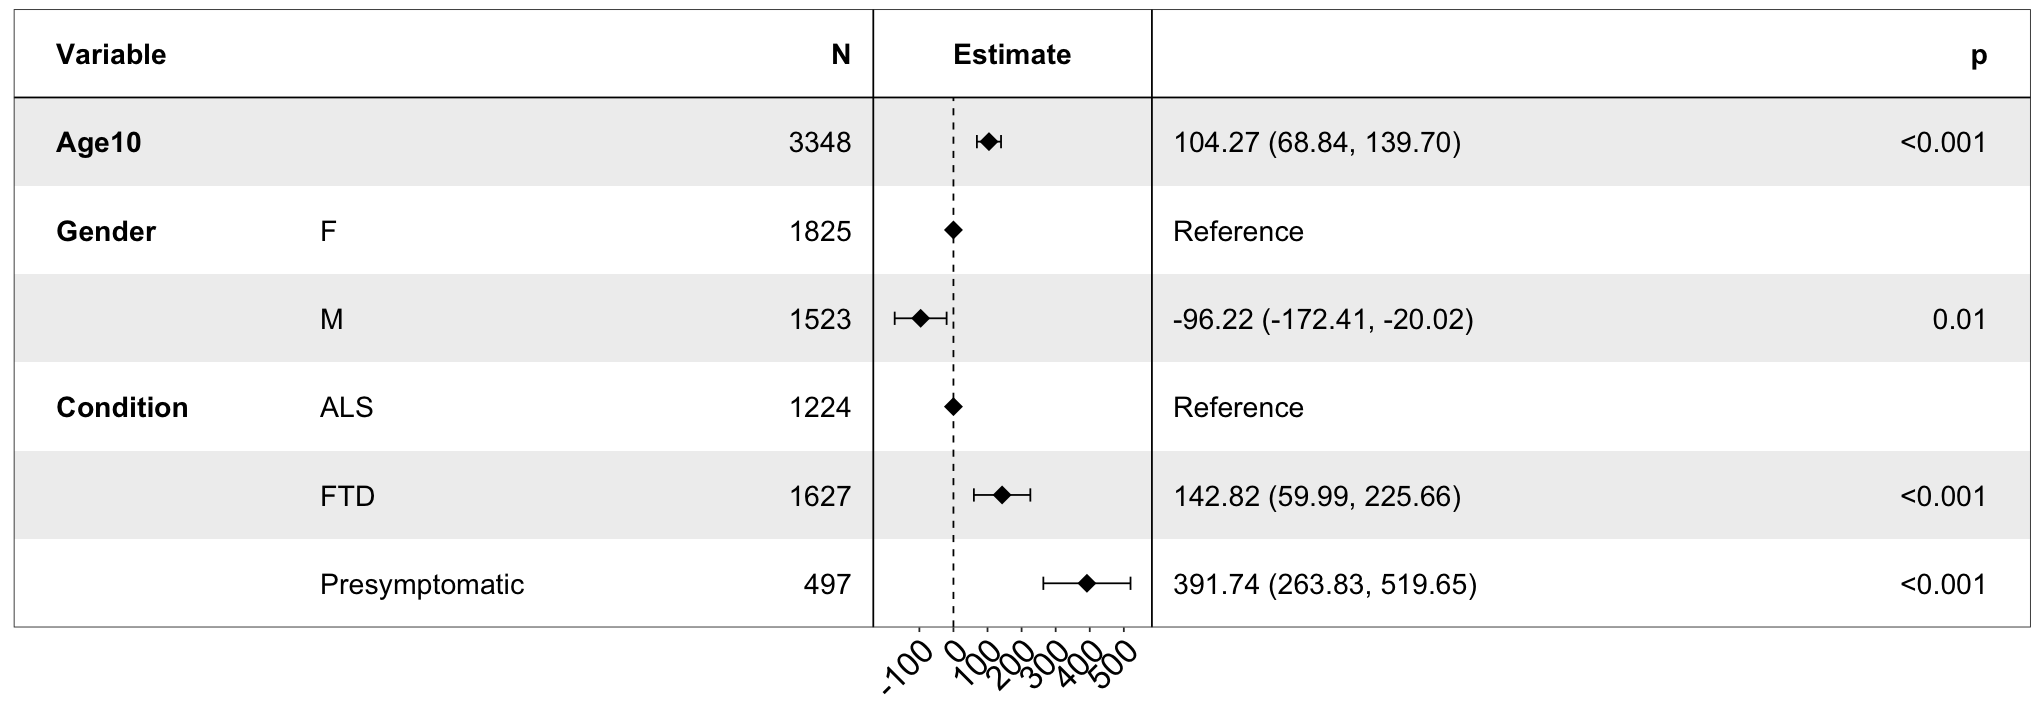

In [49]:
tmp <- dd
dim(tmp)
tmp$Age10 <- tmp$AP/10
reso <- glm(formula = repeats ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=17, repr.plot.height=6)
gf1 <- forest_model(reso,
             #panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

## Linear Mixed Model (LMM)

In [52]:
library(lme4)

In [ ]:
tmp <- dd

tmp$Age10 <- tmp$AP/10
tmp$sample <- paste0("p",tmp$Sample)
#reso <- glm(formula = repeats ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

#model <- lmer(repeats ~ Age10 + (1 | sample), data = tmp)
#model

## Simple Mean ...

In [109]:
dim(df)
head(df,2)

[1] 47 24

Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125425,64,NA,M,64+,Pre,64,2196.413,1943.458,299.5667,⋯,57,30,14,7,0.53125,0.781250,0.890625,0.46875,0.218750,0.109375
125718,41,NA,M,64-,Pre,64,1952.408,1697.283,231.8333,⋯,62,24,11,2,0.62500,0.828125,0.968750,0.37500,0.171875,0.031250



Call:  glm(formula = mean ~ Age10 + Gender + Condition, family = "gaussian", 
    data = tmp)

Coefficients:
 (Intercept)         Age10       GenderM  ConditionFTD  ConditionPre  
     1112.82        100.04        -96.68        146.27        359.33  

Degrees of Freedom: 46 Total (i.e. Null);  42 Residual
Null Deviance:	    11500000 
Residual Deviance: 10510000 	AIC: 724.3

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


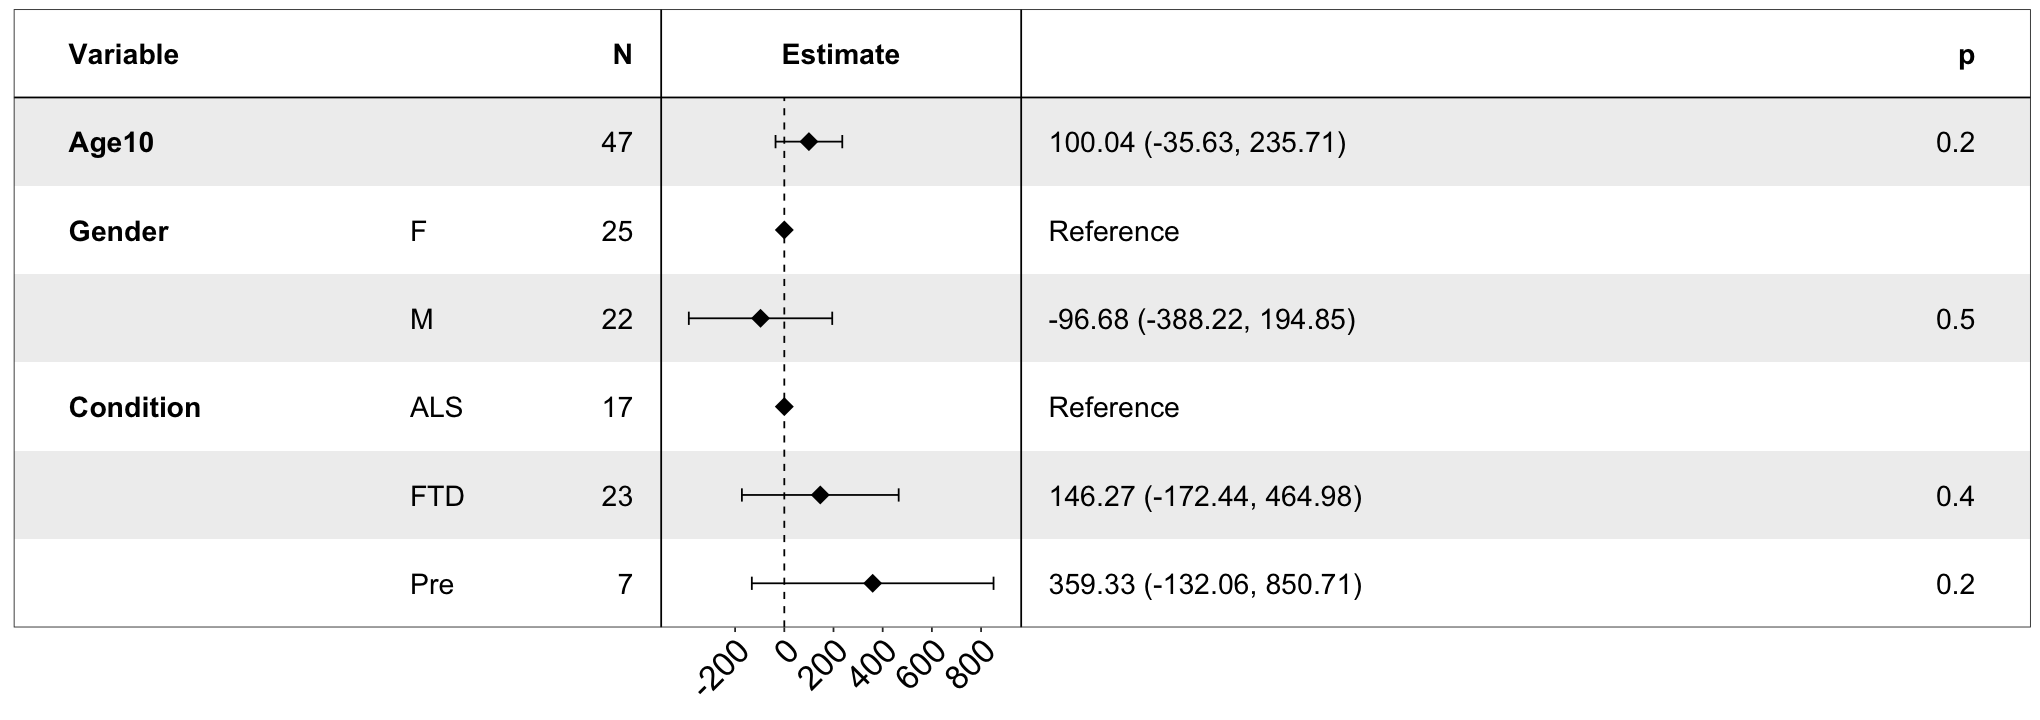

In [337]:
tmp <- df
tmp$Age10 <- tmp$AP/10
reso <- glm(formula = mean ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=17, repr.plot.height=6)
gf1 <- forest_model(reso,
             #panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

# Predictive Model for Condition

In [293]:
dim(df)
head(df,2)

[1] 47 24

Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125425,64,NA,M,64+,Pre,64,2196.413,1943.458,299.5667,⋯,57,30,14,7,0.53125,0.781250,0.890625,0.46875,0.218750,0.109375
125718,41,NA,M,64-,Pre,64,1952.408,1697.283,231.8333,⋯,62,24,11,2,0.62500,0.828125,0.968750,0.37500,0.171875,0.031250


In [295]:
summary(df$AP)
table(dff$Condition)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  31.00   54.50   64.00   61.49   71.00   89.00 


ALS FTD 
 17  23 


Call:  glm(formula = y ~ Age10 + Gender + mprop_2000, family = "binomial", 
    data = tmp)

Coefficients:
(Intercept)        Age10      GenderM   mprop_2000  
     2.7997      -0.3776      -0.2728      -1.6663  

Degrees of Freedom: 39 Total (i.e. Null);  36 Residual
Null Deviance:	    54.55 
Residual Deviance: 51.81 	AIC: 59.81

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


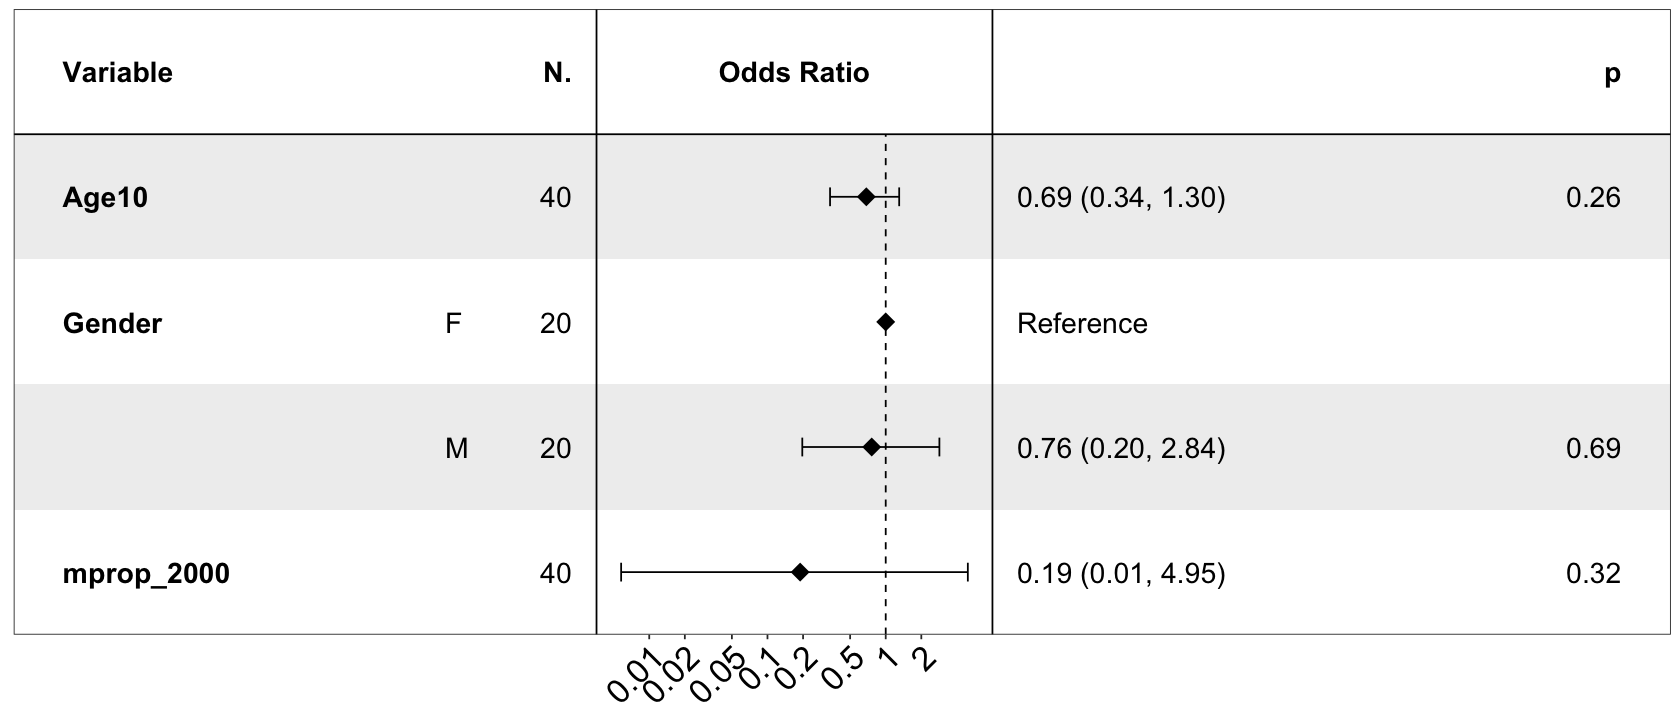

In [330]:
tmp <- dff
tmp$Age10 <- tmp$AP/10
tmp$y <- 0
tmp$y[which(tmp$Condition=="ALS")] <- 1
reso <- glm(formula = y ~  Age10 + Gender + mprop_2000, family="binomial", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=14, repr.plot.height=6)
gf1 <- forest_model(reso,
             panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

# Cohort Characteristics

In [72]:
library(gtsummary)
library(gt)


In [80]:
summary(df$n_molecules)
summary(as.numeric(dc$Molecules_count))

summary(df$mean)
summary(as.numeric(dc$Mean))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   64.00   71.00   71.23   80.50   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   64.00   71.00   71.23   80.50   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  708.1  1434.0  1862.9  1807.8  2048.8  2933.7 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  708.1  1434.0  1862.9  1807.8  2048.8  2933.7 

In [84]:
qq <- df %>% ungroup()
caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary() %>% as_gt()
gtsave(caca, filename = "table1.html")

In [114]:
qq <- df %>% ungroup()
caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary(by = Condition) %>% as_gt()
gtsave(caca, filename = "table2.html")

In [123]:
qq <- df %>% ungroup()
#caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
#  tbl_summary(by = Condition) %>%
#  add_p() %>%
#  bold_labels() %>%
#  as_gt()

caca <- qq %>%
  select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary(
    by = Condition,
    #type = all_continuous() ~ "continuous2",
    #statistic = all_continuous() ~ "{mean} ({sd})",
    missing_text = "Missing"
  ) %>%
  add_p() %>% as_gt()

gtsave(caca, filename = "table3.html")